# Dammed reaches: climate zone vs CSI

**Question:** Among RiverATLAS reaches that **host a Global Dam Watch dam** (`gdw` matched on `hyriv_id`), how does **mean FFR connectivity status (CSI)** differ by **RiverATLAS climate zone class** (`clz_cl_cmj`)?

**Why `clz_cl_cmj`:** In HydroATLAS RiverATLAS, `clz_cl_cmj` encodes the **global aridity / climate-zone classification** (integer codes). For charts we treat values as **GEnZ_ID 1–18** and join the catalog below.

**Pipeline:** `riveratlas` (reach + geometry) ⋈ `gdw` (dam on reach) ⋈ `ffr` (CSI on same `hyriv_id`). Map SQL uses `shape_length` + mild `ST_Simplify` like `dam_river_network.ipynb`. Run `clean_data.py` and `ingest.py` first; use the **repo root** as the working directory (or step up from `notebooks/`).


In [1]:
from pathlib import Path

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap

ROOT = Path.cwd().resolve()
if not (ROOT / "database" / "superbadd.duckdb").is_file():
    ROOT = ROOT.parent

DB = ROOT / "database" / "superbadd.duckdb"
con = duckdb.connect(str(DB), read_only=True)
con.execute("LOAD spatial;")

# GEnZ_ID 1–18 ↔ HydroATLAS `clz_cl_cmj` (integer); names/codes for labels only.
GENZ_CATALOG = pd.DataFrame(
    [
        (1, "A", "Arctic cold"),
        (2, "B", "Arctic"),
        (3, "C", "Subarctic cold"),
        (4, "D", "Subarctic"),
        (5, "E", "Very cold winter and dry"),
        (6, "F", "Cold and dry"),
        (7, "G", "Very cold winter and mesic"),
        (8, "H", "Cold and mesic"),
        (9, "I", "Very cold winter and wet"),
        (10, "J", "Cold and wet"),
        (11, "K", "Warm temperate and mesic"),
        (12, "L", "Warm temperate and dry"),
        (13, "M", "Warm temperate and hot"),
        (14, "N", "Hot and dry"),
        (15, "O", "Hot and mesic"),
        (16, "P", "Very hot and dry"),
        (17, "Q", "Very hot and mesic"),
        (18, "R", "Moist and hot"),
    ],
    columns=["genz_id", "genz_code", "genz_name"],
)

ZONE_HEX = [
    "#08306b", "#08519c", "#2171b5", "#4292c6", "#6baed6", "#9ecae1",
    "#c7e9c0", "#a1d99b", "#74c476", "#41ab5d", "#006d2c",
    "#fd8d3c", "#fc4e2a", "#e31a1c", "#bd0026", "#800026",
    "#4d004b", "#3c096c", "#240046", "#3b0a45",
]
zone_cmap = ListedColormap(ZONE_HEX)
zone_norm = BoundaryNorm(np.arange(0.5, 19.5, 1), zone_cmap.N)


def zone_hex_for_id(zone_id: int) -> str:
    i = int(zone_id) - 1
    if 0 <= i < len(ZONE_HEX):
        return ZONE_HEX[i]
    return "#888888"


def genz_label_row(zone_id: int, code, name) -> str:
    if pd.isna(code) or pd.isna(name):
        return str(int(zone_id))
    return f"{int(zone_id)} — {code} — {name}"


## Comparison table — mean CSI by climate zone

One row per **reach that has at least one dam** and a CSI value on the same `hyriv_id`. **`clz_cl_cmj` is treated as GEnZ_ID (1–18)** for labels via the catalog in the setup cell.


In [2]:
summary_sql = """
WITH dammed_reach AS (
    SELECT DISTINCT r.hyriv_id, r.clz_cl_cmj, f.csi AS csi
    FROM riveratlas AS r
    INNER JOIN gdw AS g ON r.hyriv_id = g.hyriv_id
    INNER JOIN ffr AS f ON f.hyriv_id = r.hyriv_id
    WHERE r.clz_cl_cmj IS NOT NULL
      AND g.hyriv_id IS NOT NULL
      AND f.csi IS NOT NULL
)
SELECT
    clz_cl_cmj AS climate_zone_code,
    COUNT(*) AS n_reaches,
    ROUND(AVG(csi), 4) AS mean_csi,
    ROUND(STDDEV(csi), 4) AS sd_csi,
    ROUND(MEDIAN(csi), 4) AS median_csi,
    MIN(csi) AS min_csi,
    MAX(csi) AS max_csi
FROM dammed_reach
GROUP BY clz_cl_cmj
ORDER BY mean_csi ASC;
"""
summary = con.execute(summary_sql).df()
summary = summary.merge(
    GENZ_CATALOG,
    how="left",
    left_on="climate_zone_code",
    right_on="genz_id",
)
summary_display = summary.rename(
    columns={
        "genz_id": "GEnZ_ID",
        "genz_code": "GEnZ_Code",
        "genz_name": "GEnZ_Name",
    }
)[
    [
        "GEnZ_ID",
        "GEnZ_Code",
        "GEnZ_Name",
        "climate_zone_code",
        "n_reaches",
        "mean_csi",
        "sd_csi",
        "median_csi",
        "min_csi",
        "max_csi",
    ]
]
summary_display


,GEnZ_ID,GEnZ_Code,GEnZ_Name,climate_zone_code,n_reaches,mean_csi,sd_csi,median_csi,min_csi,max_csi
0,3,C,Subarctic cold,3,14,32.4343,9.4026,26.7205,25.26076,54.58113
1,5,E,Very cold winter and dry,5,272,43.1816,23.0331,35.4547,25.06853,100.00000
2,15,O,Hot and mesic,15,115,53.3668,33.1309,40.6853,14.11313,100.00000
3,12,L,Warm temperate and dry,12,1800,54.5248,30.1927,47.4206,9.88962,100.00000
4,6,F,Cold and dry,6,264,56.8059,31.3457,43.4194,24.50108,100.00000
5,9,I,Very cold winter and wet,9,1327,60.3043,30.7554,52.3015,9.43539,100.00000
6,7,G,Very cold winter and mesic,7,1810,60.6039,27.3052,54.0266,19.91313,100.00000
7,8,H,Cold and mesic,8,2375,61.9519,29.2879,53.9727,10.01445,100.00000
8,13,M,Warm temperate and hot,13,2528,65.6322,25.6078,56.2000,15.52211,100.00000
9,11,K,Warm temperate and mesic,11,6565,65.8543,28.1280,56.4077,13.58915,100.00000


## Bar chart — mean CSI (zones with enough reaches)

Zones with very few reaches are noisy; we hide groups below a small **minimum n** so the chart stays readable.

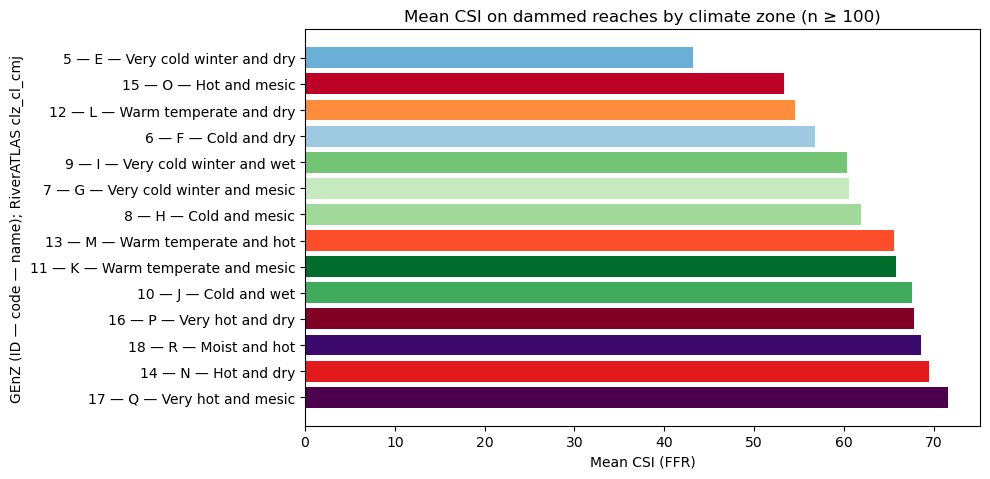

In [3]:
min_n = 100
plot_df = summary[summary["n_reaches"] >= min_n].sort_values("mean_csi", ascending=True)
plot_df = plot_df.assign(
    bar_label=plot_df.apply(
        lambda r: genz_label_row(r["climate_zone_code"], r["genz_code"], r["genz_name"]),
        axis=1,
    )
)
bar_colors = [zone_hex_for_id(int(r["climate_zone_code"])) for _, r in plot_df.iterrows()]

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
ax.barh(plot_df["bar_label"], plot_df["mean_csi"], color=bar_colors)
ax.set_xlabel("Mean CSI (FFR)")
ax.set_ylabel("GEnZ (ID — code — name); RiverATLAS clz_cl_cmj")
ax.set_title(f"Mean CSI on dammed reaches by climate zone (n ≥ {min_n})")
ax.invert_yaxis()
plt.tight_layout()


## Reach count vs mean CSI

Larger samples (more dammed reaches in a zone) tend to give stabler means; this scatter shows **volume** and **average connectivity stress** together.

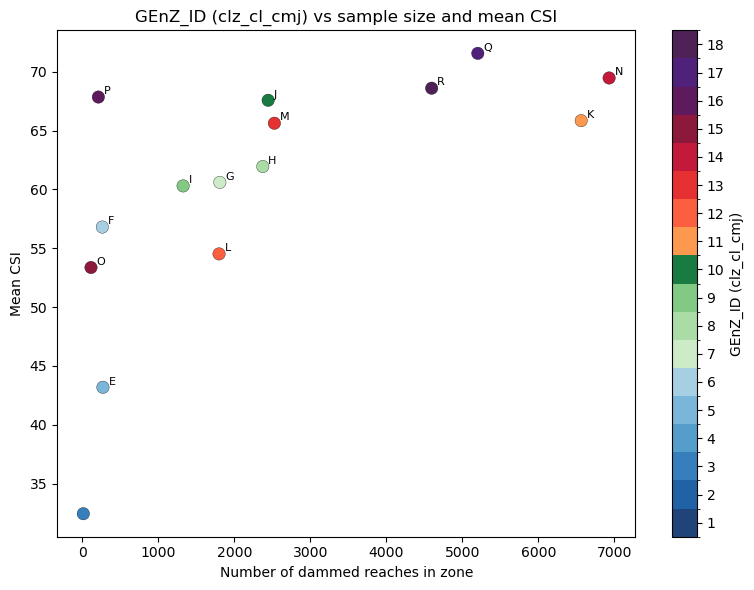

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    summary["n_reaches"],
    summary["mean_csi"],
    c=summary["climate_zone_code"],
    cmap=zone_cmap,
    norm=zone_norm,
    s=80,
    alpha=0.9,
    edgecolors="k",
    linewidths=0.25,
)
for _, row in summary.iterrows():
    if row["n_reaches"] >= min_n:
        lbl = (
            str(row["genz_code"])
            if pd.notna(row["genz_code"])
            else str(int(row["climate_zone_code"]))
        )
        ax.annotate(
            lbl,
            (row["n_reaches"], row["mean_csi"]),
            textcoords="offset points",
            xytext=(4, 2),
            fontsize=8,
        )
ax.set_xlabel("Number of dammed reaches in zone")
ax.set_ylabel("Mean CSI")
ax.set_title("GEnZ_ID (clz_cl_cmj) vs sample size and mean CSI")
cbar = plt.colorbar(sc, ax=ax, ticks=np.arange(1, 19))
cbar.set_label("GEnZ_ID (clz_cl_cmj)")
plt.tight_layout()


## Distribution of CSI within the largest zones

Boxplots show **spread**, not just the mean—useful when zones have similar averages but different variability.

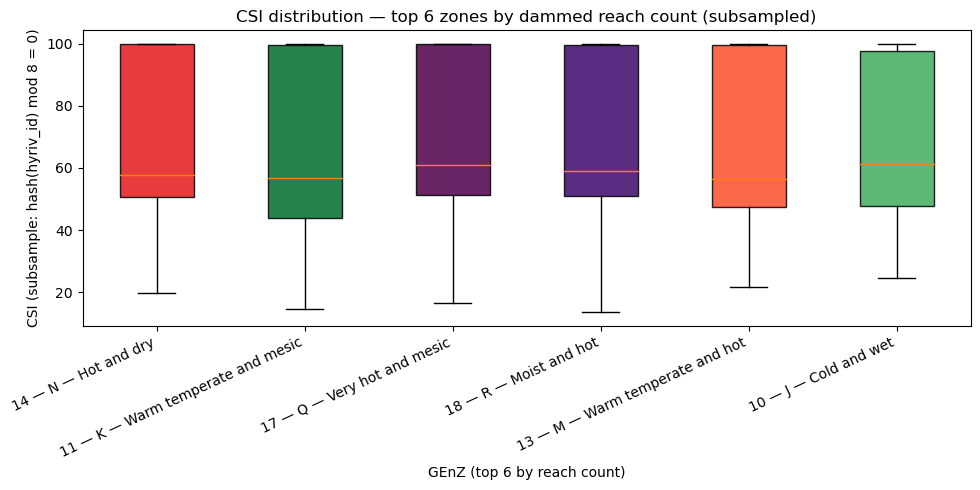

In [5]:
top_zones = summary.nlargest(6, "n_reaches")["climate_zone_code"].tolist()
zones_csv = ",".join(str(int(z)) for z in top_zones)

sample_sql = f"""
WITH dammed AS (
    SELECT DISTINCT r.hyriv_id, r.clz_cl_cmj, f.csi AS csi
    FROM riveratlas AS r
    INNER JOIN gdw AS g ON r.hyriv_id = g.hyriv_id
    INNER JOIN ffr AS f ON f.hyriv_id = r.hyriv_id
    WHERE r.clz_cl_cmj IN ({zones_csv})
      AND f.csi IS NOT NULL
)
SELECT clz_cl_cmj, csi FROM dammed
WHERE mod(abs(hash(hyriv_id)), 8) = 0;
"""
box_df = con.execute(sample_sql).df()
order = [str(int(z)) for z in top_zones]
box_df["zone_str"] = box_df["clz_cl_cmj"].astype(int).astype(str)


def _box_label(zid: int) -> str:
    row = GENZ_CATALOG.loc[GENZ_CATALOG["genz_id"] == int(zid)]
    if row.empty:
        return str(zid)
    return genz_label_row(int(zid), row.iloc[0]["genz_code"], row.iloc[0]["genz_name"])


box_labels = [_box_label(int(z)) for z in top_zones]

fig, ax = plt.subplots(figsize=(10, 5))
data = [box_df.loc[box_df["zone_str"] == z, "csi"].values for z in order]
bp = ax.boxplot(data, labels=box_labels, showfliers=False, patch_artist=True)
for patch, z in zip(bp["boxes"], order):
    patch.set_facecolor(zone_hex_for_id(int(z)))
    patch.set_alpha(0.85)
ax.set_xlabel("GEnZ (top 6 by reach count)")
ax.set_ylabel("CSI (subsample: hash(hyriv_id) mod 8 = 0)")
ax.set_title("CSI distribution — top 6 zones by dammed reach count (subsampled)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()


## Map — dammed reaches colored by climate zone

A **deterministic subsample** (`hash` mod) keeps the map responsive. **`shape_length > 0.06`** drops ultra-short reaches; **`ST_Simplify(..., 0.02)`** matches `dam_river_network.ipynb` so lines are not collapsed to empty.


map_df rows: 71
dropped empty/na geometries: 0; remaining: 71


TypeError: Colorbar.__init__() got an unexpected keyword argument 'bbox_to_anchor'

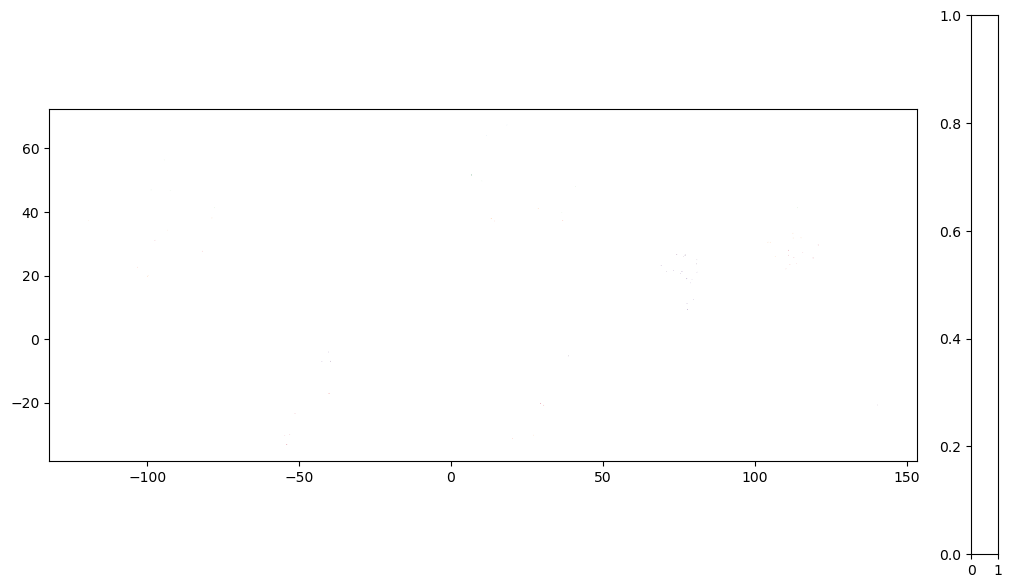

In [6]:
MAP_MIN_LEN = 0.06
MAP_SIMPLIFY_TOL = 0.02
MAP_HASH_MOD = 200

map_sql = f"""
WITH dammed AS (
    SELECT DISTINCT r.hyriv_id, r.clz_cl_cmj, f.csi
    FROM riveratlas AS r
    INNER JOIN gdw AS g ON r.hyriv_id = g.hyriv_id
    INNER JOIN ffr AS f ON f.hyriv_id = r.hyriv_id
    WHERE r.clz_cl_cmj IS NOT NULL AND f.csi IS NOT NULL
)
SELECT
    d.clz_cl_cmj,
    d.csi,
    ST_AsText(ST_Simplify(r.geometry, {MAP_SIMPLIFY_TOL})) AS wkt
FROM dammed AS d
INNER JOIN riveratlas AS r ON r.hyriv_id = d.hyriv_id
WHERE r.shape_length > {MAP_MIN_LEN}
  AND mod(abs(hash(d.hyriv_id)), {MAP_HASH_MOD}) = 0;
"""
map_df = con.execute(map_sql).df()
print(f"map_df rows: {len(map_df)}")
gdf = gpd.GeoDataFrame(
    map_df,
    geometry=gpd.GeoSeries.from_wkt(map_df["wkt"], crs="EPSG:4326"),
    crs="EPSG:4326",
)
_n0 = len(gdf)
gdf = gdf[~gdf.geometry.isna() & ~gdf.geometry.is_empty].copy()
print(f"dropped empty/na geometries: {_n0 - len(gdf)}; remaining: {len(gdf)}")

if len(gdf) == 0:
    print("Warning: no geometries to plot after filters.")
else:
    pad = 0.5
    bounds = gdf.total_bounds
    fig, ax = plt.subplots(figsize=(14, 7))
    gdf.plot(
        column="clz_cl_cmj",
        cmap=zone_cmap,
        norm=zone_norm,
        legend=True,
        legend_kwds={"label": "GEnZ_ID", "bbox_to_anchor": (1.02, 1), "loc": "upper left"},
        linewidth=0.45,
        ax=ax,
        alpha=0.88,
    )
    ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
    ax.set_ylim(bounds[1] - pad, bounds[3] + pad)
    ax.set_facecolor("#0b1020")
    ax.set_title("Subsampled dammed reaches — RiverATLAS geometry colored by GEnZ_ID (clz_cl_cmj)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()


## Map — same reaches colored by CSI (sequential)

Same geometries, color by **CSI** to see spatial structure of connectivity independent of zone code.

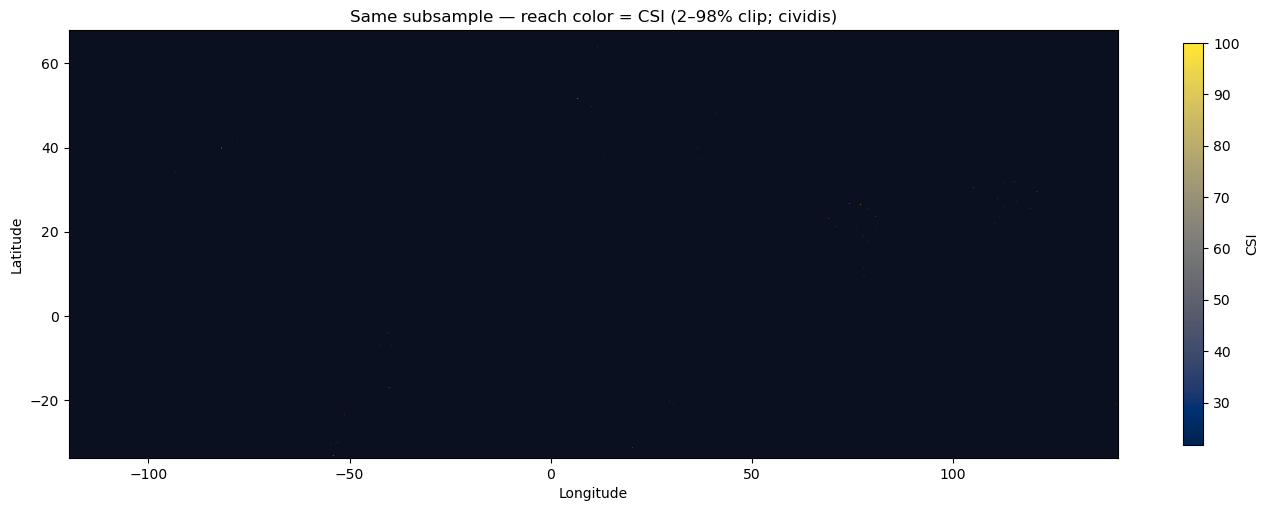

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))
if len(gdf) == 0:
    ax.text(0.5, 0.5, "No geometries (run map cell above)", ha="center", va="center", transform=ax.transAxes)
else:
    pad = 0.5
    bounds = gdf.total_bounds
    gdf.plot(
        column="csi",
        cmap="cividis",
        legend=True,
        legend_kwds={"label": "CSI", "shrink": 0.6},
        linewidth=0.4,
        ax=ax,
        vmin=gdf["csi"].quantile(0.02),
        vmax=gdf["csi"].quantile(0.98),
    )
    ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
    ax.set_ylim(bounds[1] - pad, bounds[3] + pad)
ax.set_facecolor("#0b1020")
ax.set_title("Same subsample — reach color = CSI (2–98% clip; cividis)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()


## Takeaways (fill in after you run)

- **Which `clz_cl_cmj` codes have the lowest mean CSI** on dammed reaches? (Sort the table above.)
- **Do high-n zones** sit at one end of the CSI scale, or is sample size masking weak patterns?
- **Caveats:** `clz_cl_cmj` is a **coarse global classification**; dams are not randomized across climate; CSI reflects **segment** connectivity, not only dam impact. For reporting, cite **HydroATLAS / FFR** sources from the README.

---

*Close the connection when finished.*

In [ ]:
con.close()